**Objetivo:** ¿Se puede predecir si una reseña será positiva (`voted_up`) utilizando aprendizaje supervisado basado en el texto y características del autor?

Utilizando los siguientes parametros:
- review_text
- author_playtime_at_review
- author_playtime_forever
- author_num_games_owned
- votes_funny
- language

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df_full = pd.read_csv('data/reviews.csv')
df = df_full.sample(frac=1.00, random_state=42).copy()

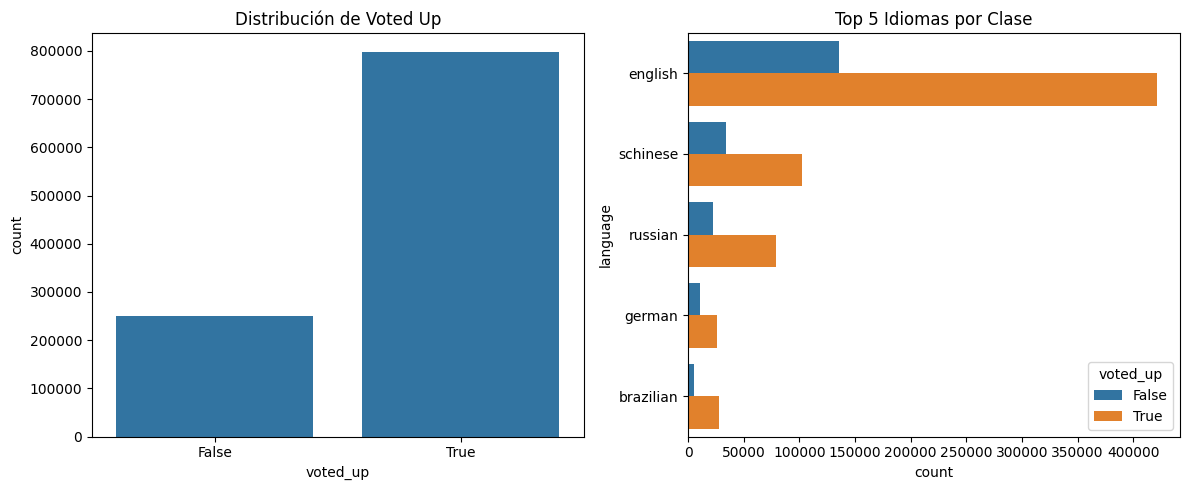

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="voted_up", ax=axes[0])
axes[0].set_title("Distribución de Voted Up")

sns.countplot(data=df, y="language", hue="voted_up", ax=axes[1], order=df['language'].value_counts().iloc[:5].index)
axes[1].set_title("Top 5 Idiomas por Clase")
plt.tight_layout()
plt.show()

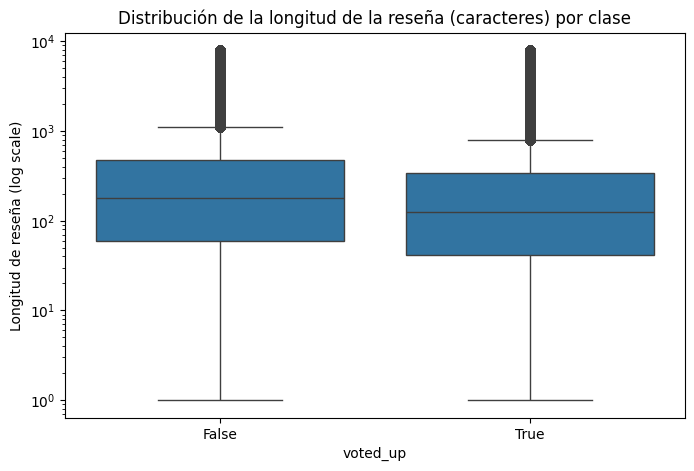

In [28]:
# Análisis de la longitud del texto de la reseña
df['review_length'] = df['review_text'].str.len()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='voted_up', y='review_length')
plt.yscale('log')
plt.title("Distribución de la longitud de la reseña (caracteres) por clase")
plt.ylabel("Longitud de reseña (log scale)")
plt.show()

df.drop(columns=['review_length'], inplace=True)

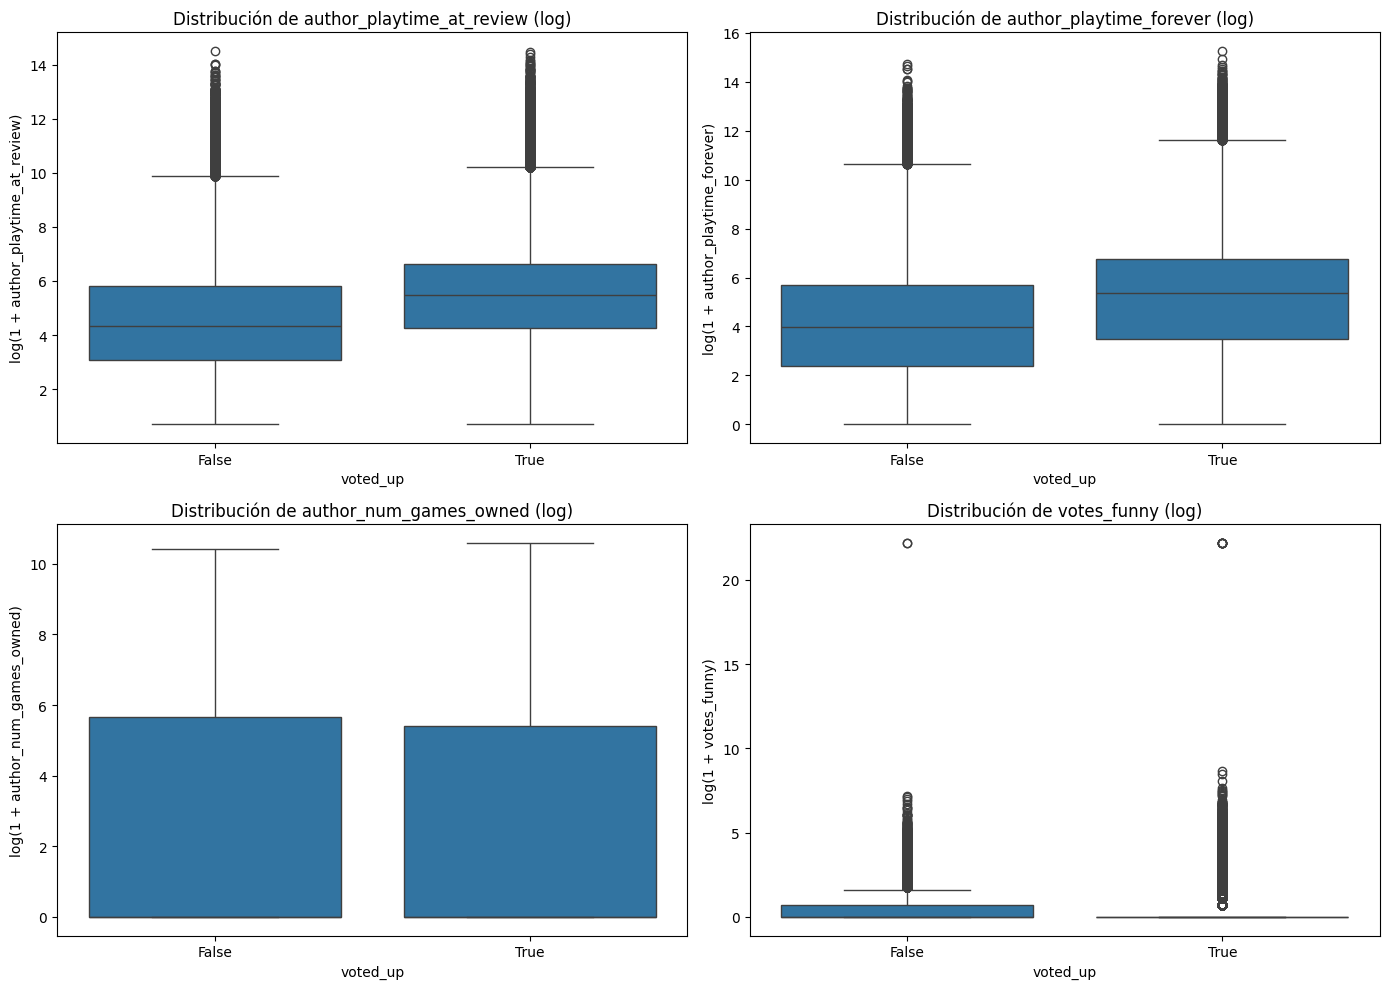

In [29]:
# Distribución de variables numéricas por clase (voted_up)
# Aplicamos escala logarítmica (log1p) debido a la asimetría de los datos

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gráfica para author_playtime_at_review
df['author_playtime_at_review_log'] = np.log1p(df['author_playtime_at_review'])
sns.boxplot(data=df, x='voted_up', y='author_playtime_at_review_log', ax=axes[0, 0])
axes[0, 0].set_title("Distribución de author_playtime_at_review (log)")
axes[0, 0].set_ylabel("log(1 + author_playtime_at_review)")

# 2. Gráfica para author_playtime_forever
df['author_playtime_forever_log'] = np.log1p(df['author_playtime_forever'])
sns.boxplot(data=df, x='voted_up', y='author_playtime_forever_log', ax=axes[0, 1])
axes[0, 1].set_title("Distribución de author_playtime_forever (log)")
axes[0, 1].set_ylabel("log(1 + author_playtime_forever)")

# 3. Gráfica para author_num_games_owned
df['author_num_games_owned_log'] = np.log1p(df['author_num_games_owned'])
sns.boxplot(data=df, x='voted_up', y='author_num_games_owned_log', ax=axes[1, 0])
axes[1, 0].set_title("Distribución de author_num_games_owned (log)")
axes[1, 0].set_ylabel("log(1 + author_num_games_owned)")

# 4. Gráfica para votes_funny
df['votes_funny_log'] = np.log1p(df['votes_funny'])
sns.boxplot(data=df, x='voted_up', y='votes_funny_log', ax=axes[1, 1])
axes[1, 1].set_title("Distribución de votes_funny (log)")
axes[1, 1].set_ylabel("log(1 + votes_funny)")

plt.tight_layout()
plt.show()

df.drop(columns=[
    'author_playtime_at_review_log', 
    'author_playtime_forever_log', 
    'author_num_games_owned_log', 
    'votes_funny_log'
], inplace=True)
